The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


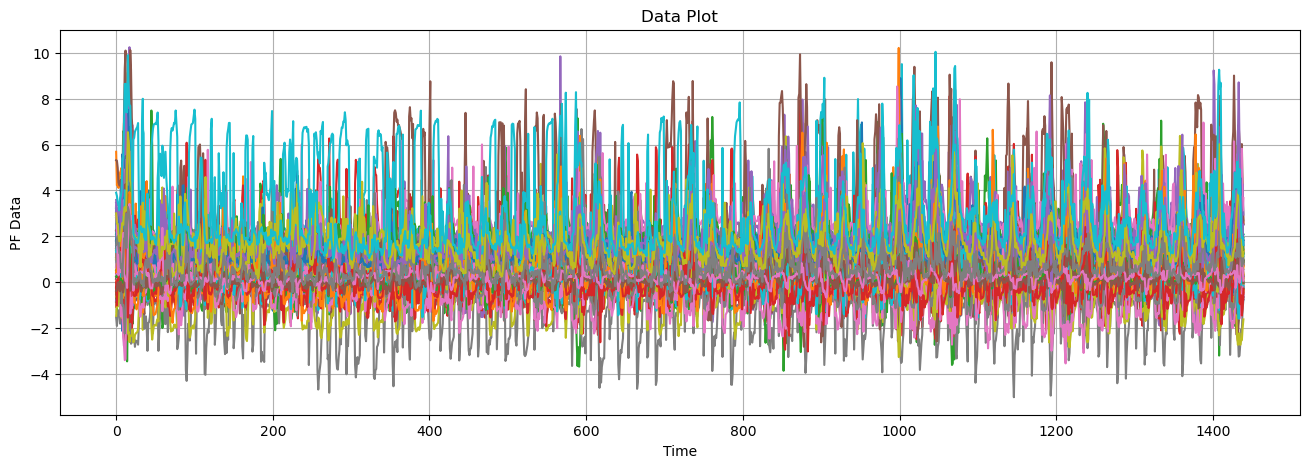

In [193]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_ac_power_flow_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw

powerID= 57
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()
outPutFile= False
# Load MATLAB file
file_name= f'matpower/test_data/DC_case{powerID}_.mat' #14, 118, 57, 30
DC_file= f'data/paper_2/results{powerID}.xlsx' # DC
_, _, H, A, _, _, _, _= ioFile.read_mat_power(file_name, normalize= False)
pfData, _=ioFile.read_excel_power(DC_file, id1= 0, id2= 0)
m= H.shape[0]
n= H.shape[1]
#
param= np.sum(np.abs(H), axis= 1, keepdims= True)/2
m= H.shape[0]
n= H.shape[1]
rankH= n-1
stdOfNoise= 1e-4
numTrain= m+ 1
#
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseE= noiseVector*stdOfNoise
pfDataE= pfData.copy()+noiseE
pfDataTrain= pfData[:m, :]
#
plotTimeSeries= True
if plotTimeSeries:
    plt.figure(figsize=(16, 5))
    for i in range(m):
        plt.plot(pfData[:, i], label=i)
    # plt.yscale("log")
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()

In [194]:
cycleListTrue= csp.minimum_topology_cycle_basis(A)

In [198]:
#dc power flow cycle basis learning
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseStd= 5e-3
noiseE= noiseVector*noiseStd
print(f"SNR: {utils.calculate_snr(pfData, noiseE):.2f} dB")
pfDataDcNoise= pfData+noiseE
trainData= pfDataDcNoise[:numTrain, :]
testData= pfDataDcNoise[numTrain: 1000, :] 
wholeRight= trainData.T.dot(trainData)
treeMethod= "robust" # "raw" or "robust"
cycleMethod= "new" # new=BIC search (no convRankedIdx); also "old" or "residual"
spaningTreeList, cycleList, treeLinks, critias= csp.recover_cycle_list(trainData, n, treeMethod=treeMethod, cycleMethod=cycleMethod)
leftLinksSet= set(range(m))-set(spaningTreeList)
print("tree:", treeLinks)
csp.check_spanning_tree(A, spaningTreeList, rankH)
csp.check_tree_links(A, rankH, treeLinks)
csp.check_cycle_list(A, cycleList, critias, H=H, dataZ=trainData)
#minimumCycleList
residual, cSpaceClean, _= resd.cycle_residual(trainData, rankH, m, testData, cycleList)
print(np.linalg.norm(residual))
residual, cSpaceClean, _= resd.cycle_residual(pfData, rankH, m, testData, cycleListTrue)
print(np.linalg.norm(residual))
#ground truth residual here
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T

SNR: 48.93 dB
tree: {44}
spaningTreeList correct: True
treeLinks correct: True
cycleList correct: False
cycleList accuracy: 23/24 (95.8%)
weighted cycleList[0] accuracy: 100.00%
weighted cycleList[1] accuracy: 100.00%
weighted cycleList[2] accuracy: 100.00%
weighted cycleList[3] accuracy: 100.00%
weighted cycleList[4] accuracy: 100.00%
weighted cycleList[5] accuracy: 100.00%
weighted cycleList[6] accuracy: 100.00%
weighted cycleList[7] accuracy: 100.00%
weighted cycleList[8] accuracy: 100.00%
weighted cycleList[9] accuracy: 100.00%
weighted cycleList[10] accuracy: 100.00%
weighted cycleList[11] accuracy: 100.00%
weighted cycleList[12] accuracy: 100.00%
weighted cycleList[13] accuracy: 100.00%
weighted cycleList[14] accuracy: 99.99%
weighted cycleList[15] accuracy: 100.00%
weighted cycleList[16] accuracy: 100.00%
weighted cycleList[17] accuracy: 100.00%
weighted cycleList[18] accuracy: 100.00%
weighted cycleList[19] accuracy: 100.00%
weighted cycleList[20] accuracy: 100.00%
weighted cyc

In [199]:
cycID= 14
residual, cSpaceClean, _= resd.cycle_residual(trainData, rankH, m, testData, cycleList)
print(cSpaceClean[:, cycID])
print(np.where(np.abs(cSpaceClean[:, cycID])>1e-2))
print(cycleList[cycID])
print(np.linalg.norm(H.T@cSpaceClean[:, cycID]))

[-0.         -0.         -0.         -0.         -0.         -0.
 -0.          0.02094522 -0.         -0.         -0.          0.08576929
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.          0.04220927 -0.06610434 -0.
 -0.0308469  -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.64178062 -0.
  0.02594464  0.1385284   0.04937135  0.03064331 -0.03567794 -0.10816809
 -0.26920661 -0.40925497 -0.          0.51710287 -0.036574   -0.03145873
 -0.01561131 -0.0528483  -0.         -0.         -0.         -0.
 -0.         -0.00413908 -0.         -0.         -0.         -0.
 -0.         -0.06848731 -0.06659962 -0.11265539  0.03623625 -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.00867739 -0.         -0.02075059 -0.0059863  -0.
 -0.02441809 -0.        ]
(array([ 7, 11, 21, 22, 24, 34, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47,
       48, 49, 61, 62, 63, 64

In [200]:
# statistic test here
statID= 30
_, _, statH, _, _, _, _, _= ioFile.read_mat_power(f'matpower/test_data/DC_case{statID}_.mat', normalize=False)
statData, _= ioFile.read_excel_power(f'data/paper_2/results{statID}.xlsx', id1=0, id2=0)
csp.compare_ranked_subspace_statistics(statData/100, statH, noiseRatio=0.1, sampleMultiples=(2, 3, 4), numTests=100, seed=0)

2m: cycleList=99.1839%, PCA=95.7081%, H known=100.0000%, cycleList>PCA 100/100, min margin=1.4927 pp, rank 100/100
3m: cycleList=99.6630%, PCA=98.0612%, H known=100.0000%, cycleList>PCA 100/100, min margin=0.9108 pp, rank 100/100
4m: cycleList=99.7884%, PCA=98.6671%, H known=100.0000%, cycleList>PCA 100/100, min margin=0.6870 pp, rank 100/100


{2: {'cycleList': array([0.99603577, 0.99252165, 0.99427848, 0.99394004, 0.98583863,
         0.98924471, 0.98970534, 0.99619552, 0.99125163, 0.99045894,
         0.99585287, 0.99511373, 0.99682133, 0.98855526, 0.99262094,
         0.98756109, 0.99074052, 0.99545056, 0.98988067, 0.98013714,
         0.99379587, 0.99272862, 0.99422224, 0.99553132, 0.99391188,
         0.99474958, 0.9854198 , 0.99533349, 0.99557773, 0.99335757,
         0.98867185, 0.9965808 , 0.99744959, 0.99477788, 0.99243824,
         0.9969667 , 0.99666369, 0.98962492, 0.99446185, 0.99678412,
         0.99697992, 0.99392425, 0.98969633, 0.98479247, 0.99396183,
         0.99246524, 0.99584247, 0.99458   , 0.99169993, 0.99396854,
         0.9911972 , 0.990825  , 0.96715196, 0.98961944, 0.99520944,
         0.99452864, 0.9909024 , 0.99264685, 0.98777009, 0.99559866,
         0.99526108, 0.99233719, 0.9960261 , 0.99073989, 0.99547039,
         0.99573257, 0.99678965, 0.9885411 , 0.98950551, 0.9908713 ,
         0.9921425

SNR: 20.02 dB
[175, 179, 183, 8, 182, 133, 172, 103, 170, 132, 181, 176, 167, 177, 128, 109, 37, 156, 174, 168, 48, 161, 69, 139, 39, 19, 60, 68, 50, 7, 6, 131, 159, 24, 112, 29, 136, 5, 73, 55, 22, 121, 58, 26, 111, 1, 78, 33, 4, 162, 143, 30, 120, 59, 93, 146, 51, 2, 62, 31, 125, 96, 185, 151, 23, 12, 45, 118, 27, 152, 71, 101, 18, 184, 76, 142, 54, 116, 89, 47, 17, 41, 20, 100, 79, 171, 72, 99, 155, 145, 124, 32, 88, 10, 82, 64, 49, 107, 129, 57, 106, 3, 66, 153, 53, 164, 11, 140, 34, 119, 127, 94, 16, 74, 84, 148, 44]
spaningTreeList correct: True
treeLinks correct: False
missing: [6, 8, 112, 132, 133, 175, 176]
extra: [7, 128]
cycleList correct: False
cycleList accuracy: 25/69 (36.2%)
weighted cycleList[0] accuracy: 99.62%
weighted cycleList[1] accuracy: 99.92%
weighted cycleList[2] accuracy: 99.84%
weighted cycleList[3] accuracy: 99.59%
weighted cycleList[4] accuracy: 99.79%
weighted cycleList[5] accuracy: 99.98%
weighted cycleList[6] accuracy: 99.46%
weighted cycleList[7] accura

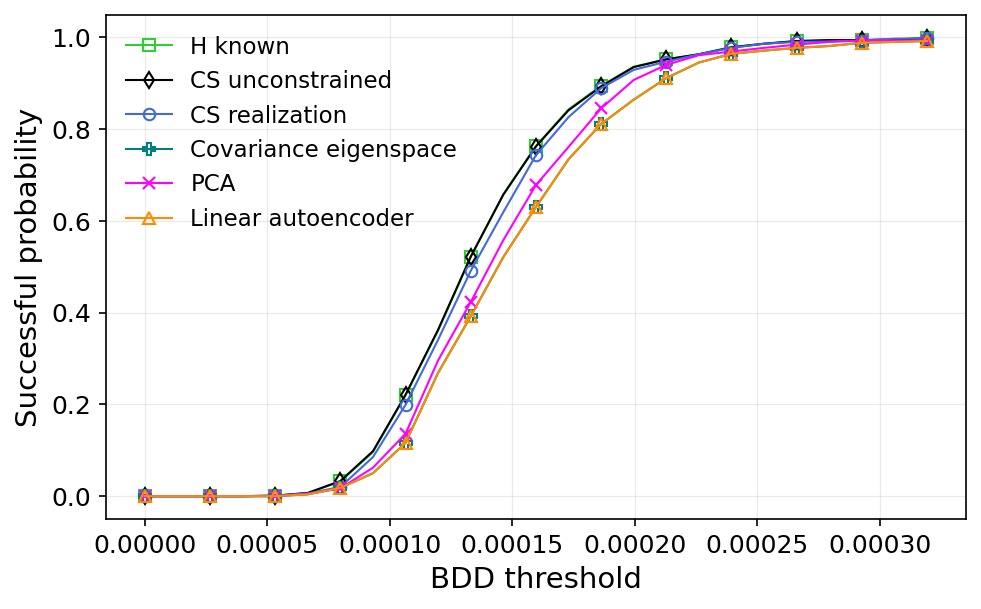

In [281]:
#bentchmark here
benchmarkID= 118
_, _, benchmarkH, benchmarkA, _, _, _, _= ioFile.read_mat_power(f'matpower/test_data/DC_case{benchmarkID}_.mat', normalize=False)
benchmarkData, _= ioFile.read_excel_power(f'data/paper_2/results{benchmarkID}.xlsx', id1=0, id2=0)
benchmarkData= benchmarkData/100 # MW to per unit, as in read_mat_power
benchmarkM, benchmarkN= benchmarkH.shape
benchmarkRank, benchmarkMER= benchmarkN-1, 4 if benchmarkID == 14 else 1 # paper Table V: IEEE-14/57
benchmarkTrainMultiple= 1 # switch among 2, 3, and 4
benchmarkTrainCount= benchmarkM*benchmarkTrainMultiple
benchmarkRng= np.random.default_rng(7)
benchmarkAttackStrength= 8.0
benchmarkProposedRank= benchmarkN- 1
benchmarkAutoencoderRank= benchmarkN # encoder m x n; decoder n x m
benchmarkCycleAttackRank= benchmarkN- 1
benchmarkNoiseStd= 0.1*np.maximum(np.sqrt(np.mean(benchmarkData[:benchmarkTrainCount]**2, axis=0)), 1e-8)
noisTrain= benchmarkRng.normal(scale=benchmarkNoiseStd, size=(benchmarkTrainCount, benchmarkM))
benchmarkTrain= benchmarkData[:benchmarkTrainCount]+noisTrain
print(f"SNR: {utils.calculate_snr(benchmarkData[:benchmarkTrainCount], noisTrain):.2f} dB")
benchmarkTreeMethod= "robust" # "raw" or "robust"
benchmarkTreeLearned, _= csp.get_spanning_tree(benchmarkTrain, benchmarkRank, benchmarkM, method=benchmarkTreeMethod)
#true tree here
benchmarkTreeTrue, _= csp.get_spanning_tree(benchmarkA.T, benchmarkRank, benchmarkM, method="raw")
benchmarkTreeSource= "learned" # switch between "true" and "learned"
benchmarkTree= benchmarkTreeTrue if benchmarkTreeSource == "true" else benchmarkTreeLearned
print(benchmarkTreeLearned)
benchmarkCycleMethod= globals().get("cycleMethod", "new")
benchmarkCycleList, treeLinks, benchmarkCritias= csp.get_cycle_basis(benchmarkTrain, benchmarkN, benchmarkTree, method=benchmarkCycleMethod)
csp.check_spanning_tree(benchmarkA, benchmarkTree, benchmarkRank)
csp.check_tree_links(benchmarkA, benchmarkRank, treeLinks)
csp.check_cycle_list(benchmarkA, benchmarkCycleList, benchmarkCritias, H=benchmarkH, dataZ=benchmarkTrain)
benchmarkCycleListTrue= csp.minimum_topology_cycle_basis(benchmarkA)
bddThresholds, successProbability, injectionMagnitude= resd.chi2_attack_success_benchmark(
    benchmarkH, benchmarkTrain, benchmarkData[benchmarkTrainCount:],
    benchmarkCycleListTrue, benchmarkCycleList, benchmarkNoiseStd,
    # attackStrength is the common whitened attack-vector norm
    numTrials=1000, attackStrength=benchmarkAttackStrength, seed=7, paperExtension=benchmarkMER,
    proposedRank=benchmarkProposedRank, autoencoderRank=benchmarkAutoencoderRank- 1,
    returnMagnitudes=True, cycleAttackRank=benchmarkCycleAttackRank)
# Covariance eigenspace: C=Zc.T@Zc/(T-1), Uhat=top eigenvectors, a=Uhat@v0.
styles= [("H known", "H known", "limegreen", "s"),
         ("cycleListTrue", "CS unconstrained", "black", "d"),
         ("cycleList", "CS realization", "royalblue", "o"),
         ("Covariance eigenspace", "Covariance eigenspace", "teal", "P"),
         ("PCA", "PCA", "magenta", "x"),
         ("Linear autoencoder", "Linear autoencoder", "darkorange", "^")]
plotLabels= {key: label for key, label, _, _ in styles}
plotLabels["Proposed (paper)"]= "RMT denoising" # retained for the numerical comparison only
fig, ax= plt.subplots(figsize=(6.48, 4.0), dpi=150) # 1.62:1, half-page figure
for key, label, color, marker in styles:
    ax.plot(bddThresholds, successProbability[key], color=color, marker=marker, label=label, linewidth=1.0, markersize=5.5, markerfacecolor="none", markeredgewidth=1.0, markevery=2)
ax.set_xlabel(r"BDD threshold", fontsize=14)
ax.set_ylabel("Successful probability", fontsize=14)
# plt.ylim(0, 1.02)
# plt.yscale("log")
# plt.xscale("log")
ax.tick_params(axis="both", labelsize=12)
ax.grid(alpha=0.25, linewidth=0.6)
ax.legend(fontsize=11, ncol=1, frameon=False)
fig.tight_layout(pad=0.5)
fig.savefig(f"figs/benchmark_ieee{benchmarkID}.pdf")
plt.show()


In [274]:
# compare subsace accuracy here
# Projection overlap: mean squared cosine of principal angles (1 = exact).
qTrue= np.linalg.svd(benchmarkH, full_matrices=False)[0][:, :benchmarkRank]
proposedRank= benchmarkProposedRank
for name in ["cycleListTrue", "cycleList", "Covariance eigenspace", "PCA", "Linear autoencoder", "Proposed (paper)"]:
    proposed= name == "Proposed (paper)"
    basis= (resd.paper_fdia_basis(benchmarkTrain, benchmarkMER, proposedRank)
            if proposed else injectionMagnitude[name]["rawVector"].T)
    basisRank= proposedRank if proposed else np.linalg.matrix_rank(basis)
    q= np.linalg.svd(basis, full_matrices=False)[0][:, :basisRank]
    overlap= np.linalg.norm(qTrue.T@q, "fro")**2
    accuracy= min(1.0, overlap/min(benchmarkRank, basisRank))
    coverage= min(1.0, overlap/benchmarkRank)
    outside= np.linalg.norm(q-qTrue@(qTrue.T@q), "fro")/np.sqrt(basisRank)
    product= benchmarkH.T@q
    print(f"{plotLabels[name]}: accuracy={100*accuracy:.4f}%, coverage={100*coverage:.4f}% (rank {basisRank}), outside Col(H)={outside:.3e}, RMS(H.T@Q)={np.sqrt(np.mean(product**2)):.3e}")

CS unconstrained: accuracy=98.6731%, coverage=98.6731% (rank 13), outside Col(H)=1.152e-01, RMS(H.T@Q)=3.975e+00
CS realization: accuracy=92.4220%, coverage=92.4220% (rank 13), outside Col(H)=2.753e-01, RMS(H.T@Q)=3.879e+00
Covariance eigenspace: accuracy=81.9764%, coverage=81.9764% (rank 13), outside Col(H)=4.245e-01, RMS(H.T@Q)=3.638e+00
PCA: accuracy=81.7700%, coverage=81.7700% (rank 13), outside Col(H)=4.270e-01, RMS(H.T@Q)=3.625e+00
Linear autoencoder: accuracy=81.9764%, coverage=81.9764% (rank 13), outside Col(H)=4.245e-01, RMS(H.T@Q)=3.638e+00
RMT denoising: accuracy=80.4932%, coverage=80.4932% (rank 13), outside Col(H)=4.417e-01, RMS(H.T@Q)=3.473e+00


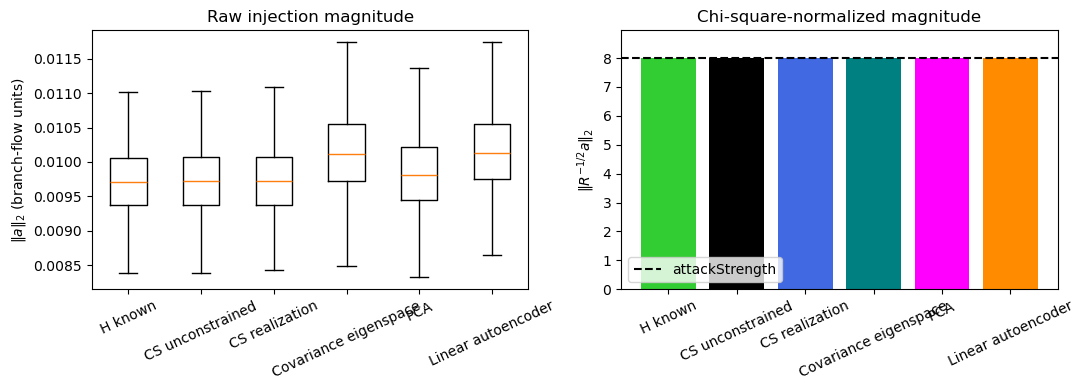

In [253]:
# plot injection magnitude
names= [x[0] for x in styles]
labels= [x[1] for x in styles]
fig, ax= plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([injectionMagnitude[x]["raw"] for x in names], tick_labels=labels, showfliers=False)
ax[0].set(title="Raw injection magnitude", ylabel=r"$\|a\|_2$ (branch-flow units)")
ax[1].bar(labels, [injectionMagnitude[x]["whitened"].mean() for x in names], color=[x[2] for x in styles])
ax[1].axhline(benchmarkAttackStrength, color="black", linestyle="--", label="attackStrength")
ax[1].set(title="Chi-square-normalized magnitude", ylabel=r"$\|R^{-1/2}a\|_2$", ylim=(0, 1.12*benchmarkAttackStrength))
ax[1].legend()
for a in ax: a.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()


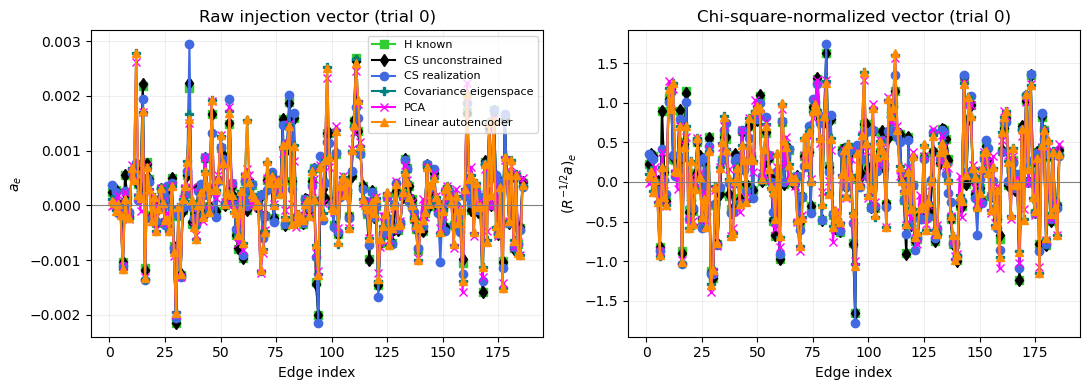

In [254]:
#plot injection vector
edgeIndex= np.arange(1, benchmarkM+1)
fig, ax= plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for key, label, color, marker in styles:
    ax[0].plot(edgeIndex, injectionMagnitude[key]["rawVector"][0], color=color, marker=marker, label=label)
    ax[1].plot(edgeIndex, injectionMagnitude[key]["whitenedVector"][0], color=color, marker=marker)
ax[0].set(title="Raw injection vector (trial 0)", xlabel="Edge index", ylabel=r"$a_e$")
ax[1].set(title="Chi-square-normalized vector (trial 0)", xlabel="Edge index", ylabel=r"$(R^{-1/2}a)_e$")
for a in ax: a.axhline(0, color="gray", linewidth=.8); a.grid(alpha=.2)
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


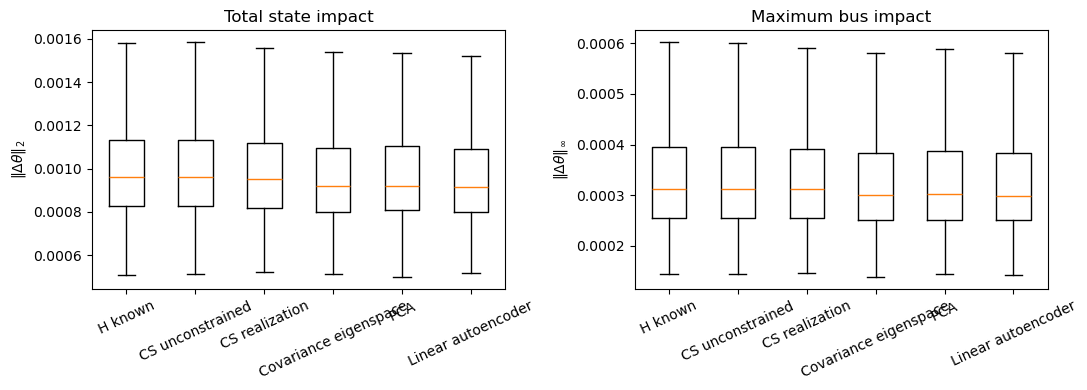

In [255]:
#plot the state impact
fig, ax= plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([injectionMagnitude[x]["stateL2"] for x in names], tick_labels=labels, showfliers=False)
ax[0].set(title="Total state impact", ylabel=r"$\|\Delta\theta\|_2$")
ax[1].boxplot([injectionMagnitude[x]["stateMax"] for x in names], tick_labels=labels, showfliers=False)
ax[1].set(title="Maximum bus impact", ylabel=r"$\|\Delta\theta\|_\infty$")
for a in ax: a.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()


In [282]:
# noise sensitivity here
noiseLevels= np.logspace(-3, -1, 12)
noiseTrials= 20
noiseLevels, noiseAccuracy= resd.noise_sensitivity_accuracy(
    benchmarkH, benchmarkData[:benchmarkTrainCount], benchmarkCycleListTrue,
    noiseLevels=noiseLevels, numTrials=noiseTrials, seed=17,
    treeMethod=benchmarkTreeMethod, cycleMethod=benchmarkCycleMethod,
    autoencoderRank=benchmarkAutoencoderRank-1, verbose=True)
noisePercent= 100*noiseLevels

noise=0.001: H known=100.000%, cycleListTrue=100.000%, cycleList=100.000%, Covariance eigenspace=99.998%, PCA=99.998%, Linear autoencoder=99.998%
noise=0.00152: H known=100.000%, cycleListTrue=100.000%, cycleList=100.000%, Covariance eigenspace=99.996%, PCA=99.996%, Linear autoencoder=99.996%
noise=0.00231: H known=100.000%, cycleListTrue=100.000%, cycleList=100.000%, Covariance eigenspace=99.991%, PCA=99.991%, Linear autoencoder=99.991%
noise=0.00351: H known=100.000%, cycleListTrue=100.000%, cycleList=100.000%, Covariance eigenspace=99.980%, PCA=99.980%, Linear autoencoder=99.980%
noise=0.00534: H known=100.000%, cycleListTrue=100.000%, cycleList=99.999%, Covariance eigenspace=99.954%, PCA=99.954%, Linear autoencoder=99.954%
noise=0.00811: H known=100.000%, cycleListTrue=100.000%, cycleList=99.998%, Covariance eigenspace=99.893%, PCA=99.894%, Linear autoencoder=99.893%
noise=0.0123: H known=100.000%, cycleListTrue=99.999%, cycleList=99.995%, Covariance eigenspace=99.751%, PCA=99.756%

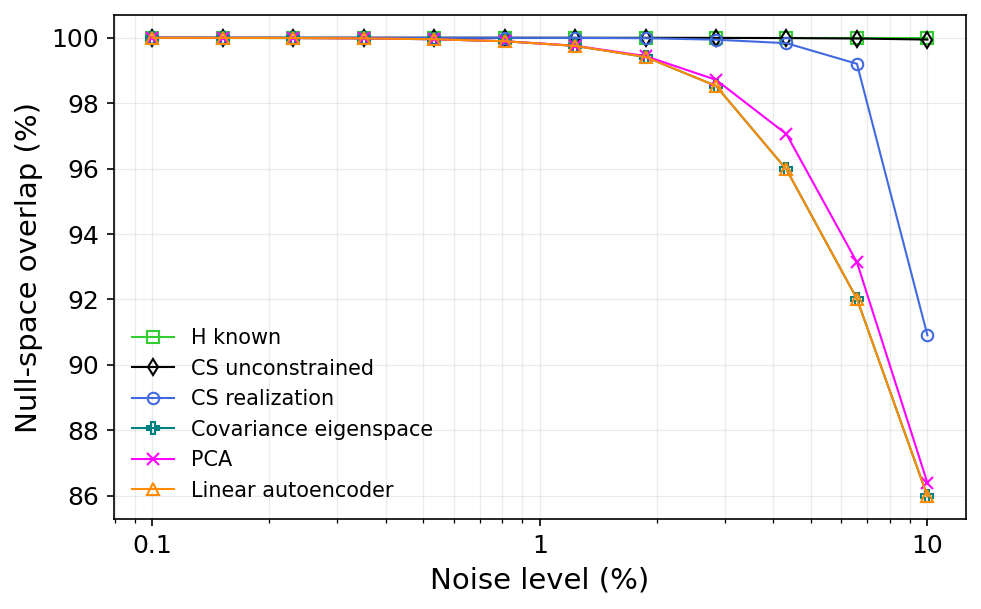

In [283]:
fig, ax= plt.subplots(figsize=(6.48, 4.0), dpi=150)
for key, label, color, marker in styles:
    values= 100*noiseAccuracy[key]
    mean= values.mean(axis=1)
    ci95= 1.96*values.std(axis=1, ddof=1)/np.sqrt(noiseTrials)
    ax.plot(noisePercent, mean, color=color, marker=marker, label=label, linewidth=1.0, markersize=5.5, markerfacecolor="none", markeredgewidth=1.0)
    # if key != "H known":
    #     ax.fill_between(noisePercent, np.clip(mean-ci95, 0, 100), np.clip(mean+ci95, 0, 100), color=color, alpha=0.08, linewidth=0)
ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xticks([0.1, 1, 10], labels=["0.1", "1", "10"])
ax.set_xlabel("Noise level (%)", fontsize=14)
ax.set_ylabel("Null-space overlap (%)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(which="both", alpha=0.25, linewidth=0.6)
ax.legend(fontsize=10, ncol=1, frameon=False)
fig.tight_layout(pad=0.5)
fig.savefig(f"figs/noise_sensitivity_ieee{benchmarkID}.pdf")
plt.show()

num links
20
20
num links


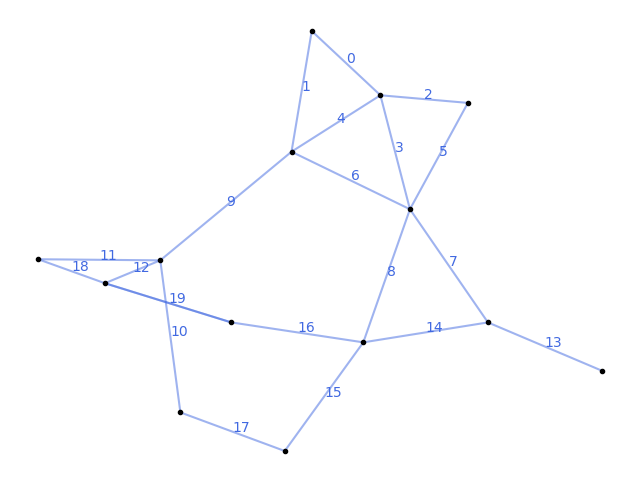

In [70]:
G, node_pair2id= graph.from_A_to_G(A[:, :])
G, _= graph.from_A_to_G(A[:, :])
print("num links")
print(G.number_of_edges())
print(m)
print("num links")
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))
plotGraph.plot_spring_layout(G, label= False, label_edge= True, node_pair2id= node_pair2id)